In [9]:
import os
import numpy as np 
import pandas as pd
import cv2
import shutil
from glob import glob
import matplotlib.pyplot as plt
import xml.etree.ElementTree as xet
from sklearn.model_selection import train_test_split

import torch

print(f'{torch.cuda.is_available()=}')
print(f'{torch.cuda.device_count()=}')



torch.cuda.is_available()=True
torch.cuda.device_count()=2


In [10]:
!pip install ultralytics

In [11]:
!pip install -U ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 3.1 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 8.1.5
    Uninstalling ipywidgets-8.1.5:
      Successfully uninstalled ipywidgets-8.1.5


In [12]:
dataset_path='/kaggle/input/datasets/andrewmvd/car-plate-detection'

In [13]:
import re

def the_number_in_the_string(filename):
    match=re.search(r'(\d+)',filename) #/d -all digits
    if match:
        return int(match.group(0))
    else:
        return 0
        

In [14]:
print(the_number_in_the_string("file123.txt"))

123


In [15]:
labels_dict=dict(
    img_path=[],
    xmin=[],
    xmax=[],
    ymin=[],
    ymax=[],
    img_w=[],
    img_h=[]
)

In [16]:
labels_dict

{'img_path': [],
 'xmin': [],
 'xmax': [],
 'ymin': [],
 'ymax': [],
 'img_w': [],
 'img_h': []}

In [17]:
import os
from glob import glob

xml_files=glob(f'{dataset_path}/annotations/*.xml') # *.xml-all files who has xml
xml_files

['/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars339.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars13.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars74.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars16.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars291.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars236.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars429.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars132.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars251.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars51.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars165.xml',
 '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars313.xml',
 '/kaggle/input/datasets/andrewm

In [18]:
import xml.etree.ElementTree as xet

In [19]:
import cv2

for filename in sorted(xml_files,key=the_number_in_the_string):
    info=xet.parse(filename)
    root=info.getroot()
    # print(info)
    # print(root)

    member_object=root.find('object')
    labels_info=member_object.find('bndbox')
    # print(member_object,labels_info)

    xmin=int(labels_info.find('xmin').text)
    xmax=int(labels_info.find('xmax').text)
    ymin=int(labels_info.find('ymin').text)
    ymax=int(labels_info.find('ymax').text)
    # print(xmin,xmax,ymin,ymax)

    img_name=root.find('filename').text
    img_path=os.path.join(dataset_path,'images',img_name)  
    # print(img_name,img_path)

    #Height & Width
    height,width,_ =cv2.imread(img_path).shape
    # print("\nHeight is:",height,"\nWidth is:",width)

    labels_dict['img_path'].append(img_path)
    labels_dict['xmin'].append(xmin)
    labels_dict['xmax'].append(xmax)
    labels_dict['ymin'].append(ymin)
    labels_dict['ymax'].append(ymax)
    labels_dict['img_w'].append(width)
    labels_dict['img_h'].append(height)
    # print(labels_dict)
    
    # break

In [20]:
#Converted all XML information into dataframe
alldata=pd.DataFrame(labels_dict)
alldata

,img_path,xmin,xmax,ymin,ymax,img_w,img_h
0,/kaggle/input/datasets/andrewmvd/car-plate-det...,226,419,125,173,500,268
1,/kaggle/input/datasets/andrewmvd/car-plate-det...,134,262,128,160,400,248
2,/kaggle/input/datasets/andrewmvd/car-plate-det...,229,270,176,193,400,400
3,/kaggle/input/datasets/andrewmvd/car-plate-det...,142,261,128,157,400,225
4,/kaggle/input/datasets/andrewmvd/car-plate-det...,156,503,82,253,590,350
...,...,...,...,...,...,...,...
428,/kaggle/input/datasets/andrewmvd/car-plate-det...,142,258,128,157,400,225
429,/kaggle/input/datasets/andrewmvd/car-plate-det...,86,208,166,195,301,400
430,/kaggle/input/datasets/andrewmvd/car-plate-det...,38,116,159,197,400,225
431,/kaggle/input/datasets/andrewmvd/car-plate-det...,55,343,82,147,400,192


In [22]:
train

,img_path,xmin,xmax,ymin,ymax,img_w,img_h
124,/kaggle/input/datasets/andrewmvd/car-plate-det...,305,320,256,267,400,267
315,/kaggle/input/datasets/andrewmvd/car-plate-det...,12,385,98,181,400,300
282,/kaggle/input/datasets/andrewmvd/car-plate-det...,37,319,145,203,350,263
236,/kaggle/input/datasets/andrewmvd/car-plate-det...,223,250,106,119,400,176
112,/kaggle/input/datasets/andrewmvd/car-plate-det...,49,164,135,191,240,400
...,...,...,...,...,...,...,...
110,/kaggle/input/datasets/andrewmvd/car-plate-det...,286,328,133,159,400,267
255,/kaggle/input/datasets/andrewmvd/car-plate-det...,116,273,156,188,400,267
292,/kaggle/input/datasets/andrewmvd/car-plate-det...,91,137,187,208,400,267
54,/kaggle/input/datasets/andrewmvd/car-plate-det...,148,257,61,118,400,300


In [23]:
#Convert this xim,xmax.. into yolo format and save it into text format

In [24]:
os.path.splitext(os.path.basename('/kaggle/input/datasets/andrewmvd/car-plate-detection/iamges/Cars1.png'))

('Cars1', '.png')

In [27]:
import os
import shutil
from sklearn.model_selection import train_test_split

train, test = train_test_split(alldata, test_size=1/10, random_state=42)
train, val = train_test_split(train, train_size=8/9, random_state=42)

print(f"""
len(train) = {len(train)}
len(val)   = {len(val)}
len(test)  = {len(test)}
""")

#Create in YOLO Format
def make_split_folder_in_yolo_format(split_name, split_df):

    labels_path = os.path.join('datasets', 'cars_license_plate_new', split_name, 'labels')
    images_path = os.path.join('datasets', 'cars_license_plate_new', split_name, 'images')

    os.makedirs(labels_path, exist_ok=True)
    os.makedirs(images_path, exist_ok=True)

    for _, row in split_df.iterrows():

        # Extract image name and extension
        img_name, img_extension = os.path.splitext(os.path.basename(row['img_path']))

        # YOLO format conversion
        x_center = ((row['xmin'] + row['xmax']) / 2) / row['img_w']
        y_center = ((row['ymin'] + row['ymax']) / 2) / row['img_h']
        width = (row['xmax'] - row['xmin']) / row['img_w']
        height = (row['ymax'] - row['ymin']) / row['img_h']

        # Save label file
        label_path = os.path.join(labels_path, f'{img_name}.txt')
        with open(label_path, 'w') as file:
            file.write(f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

        # Copy image
        shutil.copy(row['img_path'], os.path.join(images_path, img_name + img_extension))

    print(f"{split_name} folder created successfully!")

make_split_folder_in_yolo_format("train", train)
make_split_folder_in_yolo_format("val", val)
make_split_folder_in_yolo_format("test", test)


len(train) = 345
len(val)   = 44
len(test)  = 44

✅ train folder created successfully!
✅ val folder created successfully!
✅ test folder created successfully!


In [33]:
datasets_yaml = '''
path: cars_license_plate_new

train: train/images
val: val/images
test: test/images

nc: 1
names: ['license_plate']
'''

with open('datasets.yaml', 'w') as file:
    file.write(datasets_yaml)

In [34]:
from ultralytics import YOLO

In [35]:
model=YOLO('yolov8n.pt') #n-nano model

In [36]:
model.train(
    data='datasets.yaml',
    epochs=100,
    batch=16,
    device='cuda',
    imgsz=320,
    cache=True #Will speed up procedure
)

Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e51bbd075f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [37]:
log_dir=max(glob('runs/detect/train*'),key=the_number_in_the_string)

results=pd.read_csv(os.path.join(log_dir,'results.csv'))
results

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,6.37959,1.72418,3.00185,1.32324,0.00427,0.90909,0.09760,0.04531,1.54666,3.09878,1.11444,0.000420,0.000420,0.000420
1,2,8.83266,1.58218,1.63423,1.15840,0.00501,0.90909,0.10760,0.07544,1.66910,3.24788,1.17697,0.000851,0.000851,0.000851
2,3,11.21610,1.57136,1.50129,1.19464,0.91155,0.15909,0.43844,0.24291,1.51828,2.53535,1.18328,0.001274,0.001274,0.001274
3,4,13.52550,1.54312,1.37735,1.15641,0.58954,0.29385,0.35550,0.16171,1.80932,2.51489,1.32706,0.001688,0.001688,0.001688
4,5,15.81190,1.51866,1.31462,1.16479,0.63701,0.45455,0.53983,0.27713,1.65474,1.97535,1.26996,0.001921,0.001921,0.001921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,218.47300,0.88263,0.50024,0.95912,0.90071,0.88636,0.91504,0.53100,1.37168,0.70373,1.19157,0.000119,0.000119,0.000119
96,97,220.67500,0.90656,0.49559,0.96920,0.86588,0.88636,0.91365,0.54531,1.36023,0.69524,1.19055,0.000099,0.000099,0.000099
97,98,222.85100,0.89385,0.47519,0.96117,0.85953,0.86364,0.87853,0.53922,1.35997,0.69503,1.18667,0.000079,0.000079,0.000079
98,99,224.96000,0.88574,0.48316,0.94656,0.82014,0.86364,0.87202,0.53496,1.36648,0.69890,1.18454,0.000060,0.000060,0.000060


In [39]:
results.columns=results.columns.str.strip()

epochs=results.index + 1
print(epochs)

RangeIndex(start=1, stop=101, step=1)


In [40]:
results.columns

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')

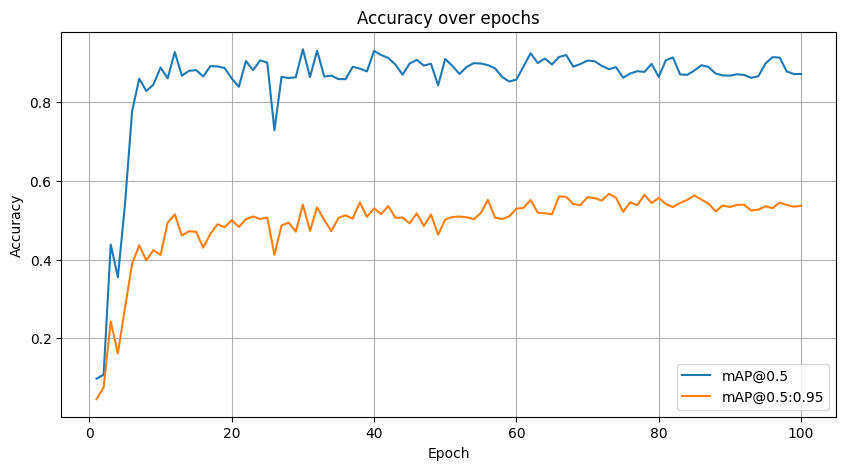

In [49]:
import matplotlib.pyplot as plt

map_0_5 = results['metrics/mAP50(B)']
map_0_5_0_95 = results['metrics/mAP50-95(B)']

plt.figure(figsize=(10,5))
plt.plot(epochs, map_0_5, label='mAP@0.5')
plt.plot(epochs, map_0_5_0_95, label='mAP@0.5:0.95')

plt.xlabel('Epoch')   # ✅ FIXED
plt.ylabel('Accuracy')
plt.title('Accuracy over epochs')

plt.legend()
plt.grid(True)
plt.show()

In [50]:
model.save('best_license_plate_model.pt')

In [51]:
 results=model.predict('/kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars1.png')


image 1/1 /kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars1.png: 224x320 1 license_plate, 45.4ms
Speed: 0.9ms preprocess, 45.4ms inference, 1.7ms postprocess per image at shape (1, 3, 224, 320)


In [52]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'license_plate'}
 obb: None
 orig_img: array([[[249, 243, 223],
         [252, 247, 228],
         [252, 244, 225],
         ...,
         [254, 255, 253],
         [253, 254, 253],
         [254, 255, 254]],
 
        [[249, 243, 224],
         [252, 247, 228],
         [251, 244, 225],
         ...,
         [254, 255, 253],
         [254, 255, 254],
         [255, 255, 254]],
 
        [[248, 244, 224],
         [251, 248, 228],
         [248, 244, 224],
         ...,
         [254, 255, 253],
         [254, 255, 254],
         [255, 255, 254]],
 
        ...,
 
        [[ 72,  62,  55],
         [ 84,  74,  67],
         [ 81,  71,  65],
         ...,
         [175, 186, 191],
         [182, 192, 197],
         [176, 186, 191]],
 
        [[ 74,  64,  57],
         [ 80,  69,  63],
         [ 84,  73,  67],
         ...,
         [1

In [110]:
#Convert this Number Plate into Text Format

#Object Character Recognition

!pip3 install pytesseract

In [105]:
import pytesseract
from pytesseract import Output

In [119]:
image=cv2.imread('/kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars77.png')
results = model.predict(
    source='/kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars77.png',
    save=True,
    conf=0.5
)


image 1/1 /kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars77.png: 224x320 1 license_plate, 8.0ms
Speed: 1.2ms preprocess, 8.0ms inference, 1.3ms postprocess per image at shape (1, 3, 224, 320)
Results saved to /kaggle/working/runs/detect/predict


ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0.], device='cuda:0')
conf: tensor([0.7495], device='cuda:0')
data: tensor([[230.9146, 157.1065, 309.2398, 180.6029,   0.7495,   0.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (270, 400)
shape: torch.Size([1, 6])
xywh: tensor([[270.0772, 168.8547,  78.3252,  23.4965]], device='cuda:0')
xywhn: tensor([[0.6752, 0.6254, 0.1958, 0.0870]], device='cuda:0')
xyxy: tensor([[230.9146, 157.1065, 309.2398, 180.6029]], device='cuda:0')
xyxyn: tensor([[0.5773, 0.5819, 0.7731, 0.6689]], device='cuda:0')
Detected License Plate Number: HR 26CU6799)



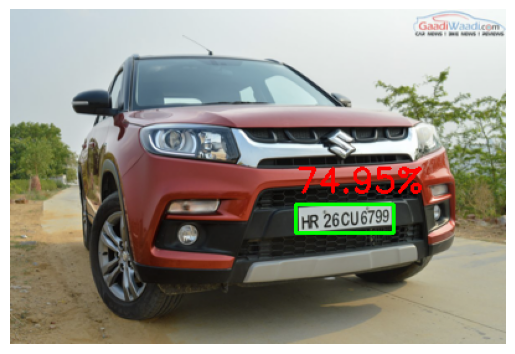

In [120]:


image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

for result in results:
    for box in result.boxes:
        print(box)
        x1,y1,x2,y2=map(int,box.xyxy[0])
        confidence=box.conf[0]

        cv2.rectangle(image,(x1,y1),(x2,y2),(0,255,0),2)
        cv2.putText(image,f'{confidence*100:.2f}%',(x1,y1-10),
                   cv2.FONT_HERSHEY_SIMPLEX,0.9,(255,0,0),2)

        roi=image[y1:y2,x1:x2]
        test=pytesseract.image_to_string(roi,config='--psm 6')
        print(f"Detected License Plate Number: {test}")
plt.imshow(image)
plt.axis('off')
plt.show()